Nombre: Flavio Zapana Ticona

# Clustering usando PSO (Particle Swarm Optimization)

En este trabajo se aplica el algoritmo de optimización por enjambre de partículas (PSO) para resolver un problema de clustering.

Se utiliza el dataset Iris, el cual contiene mediciones de flores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [2]:
data = load_iris()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Mostrar primeras filas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# CARGA DEL DATASET

data = load_iris()

X = data.data
y = data.target

print(f"Dataset cargado: {X.shape[0]} muestras, {X.shape[1]} características")
print(f"Clases: {np.unique(y)}")
print("Clases:", data.target_names)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

Dataset cargado: 150 muestras, 4 características
Clases: [0 1 2]
Clases: ['setosa' 'versicolor' 'virginica']


## Función de aptitud

La función de aptitud mide la calidad de los clusters calculando la distancia total entre los puntos y su centroide más cercano.

In [4]:
def fitness(particle, num_clusters, dim, X_data):
    """
    Calcula la suma de distancias de cada punto al centroide más cercano.
    """
    # Convertir el vector plano de la partícula en matriz de centroides
    centers = particle.reshape(num_clusters, dim)

    # Calcular distancia de cada punto a cada centroide
    distances = np.linalg.norm(X_data[:, None] - centers, axis=2)

    # Retornar la suma de las distancias mínimas (métrica de error)
    return np.sum(np.min(distances, axis=1))

## Definición de parámetros

Se establecen los parámetros del algoritmo PSO como el número de partículas, clusters e iteraciones.

In [5]:
# PARÁMETROS DEL ALGORITMO PSO
num_particles = 30     # número de partículas (soluciones)
num_clusters = 3       # número de grupos a encontrar
dim = X.shape[1]       # dimensiones del dataset
iterations = 50        # iteraciones del algoritmo

# coeficientes PSO
w = 0.5   # inercia
c1 = 1.5  # aprendizaje personal
c2 = 1.5  # aprendizaje global


## Inicialización del enjambre

Cada partícula representa posibles centroides en el espacio de búsqueda.

In [6]:
# INICIALIZACIÓN
# Inicializamos partículas usando puntos aleatorios del dataset para mayor eficiencia
particles = np.zeros((num_particles, num_clusters * dim))
for p in range(num_particles):
    indices = np.random.choice(len(X), num_clusters, replace=False)
    particles[p] = X[indices].flatten()

velocities = np.zeros_like(particles)
pbest = particles.copy()
pbest_scores = np.array([fitness(p, num_clusters, dim, X) for p in particles])

gbest_idx = np.argmin(pbest_scores)
gbest = pbest[gbest_idx].copy()
gbest_score = pbest_scores[gbest_idx]

print("Enjambre inicializado correctamente.")

Enjambre inicializado correctamente.


## Ejecución del algoritmo PSO Ciclo de Optimización (Evolución)

Las partículas actualizan su posición en función de su mejor posición individual y la mejor posición global.

In [7]:
# CICLO PRINCIPAL PSO

for i in range(iterations):

    # -------------------------
    # 1. EVALUAR PARTÍCULAS
    # -------------------------
    for j in range(num_particles):

        score = fitness(particles[j], num_clusters, dim, X)

        # actualizar pbest
        if score < pbest_scores[j]:
            pbest[j] = particles[j].copy()
            pbest_scores[j] = score

        # actualizar gbest
        if score < gbest_score:
            gbest = particles[j].copy()
            gbest_score = score

    # -------------------------
    # 2. ACTUALIZAR POSICIONES
    # -------------------------
    for j in range(num_particles):

        r1, r2 = np.random.rand(), np.random.rand()

        velocities[j] = (
            w * velocities[j]
            + c1 * r1 * (pbest[j] - particles[j])
            + c2 * r2 * (gbest - particles[j])
        )

        particles[j] += velocities[j]

    print(f"Iteración {i+1}/{iterations} | Mejor score: {gbest_score:.4f}")

Iteración 1/50 | Mejor score: 32.6791
Iteración 2/50 | Mejor score: 31.1852
Iteración 3/50 | Mejor score: 31.1852
Iteración 4/50 | Mejor score: 31.0442
Iteración 5/50 | Mejor score: 30.9090
Iteración 6/50 | Mejor score: 30.7506
Iteración 7/50 | Mejor score: 30.4377
Iteración 8/50 | Mejor score: 30.4377
Iteración 9/50 | Mejor score: 30.3847
Iteración 10/50 | Mejor score: 30.3847
Iteración 11/50 | Mejor score: 30.3513
Iteración 12/50 | Mejor score: 30.2874
Iteración 13/50 | Mejor score: 30.2440
Iteración 14/50 | Mejor score: 30.1762
Iteración 15/50 | Mejor score: 30.1318
Iteración 16/50 | Mejor score: 30.1251
Iteración 17/50 | Mejor score: 30.1074
Iteración 18/50 | Mejor score: 30.0922
Iteración 19/50 | Mejor score: 30.0764
Iteración 20/50 | Mejor score: 30.0600
Iteración 21/50 | Mejor score: 30.0459
Iteración 22/50 | Mejor score: 30.0410
Iteración 23/50 | Mejor score: 30.0323
Iteración 24/50 | Mejor score: 30.0275
Iteración 25/50 | Mejor score: 30.0185
Iteración 26/50 | Mejor score: 30.

## Resultados

Se muestran los centroides encontrados por el algoritmo.

In [8]:
# CENTROIDES ÓPTIMOS

centers = gbest.reshape(num_clusters, dim)

print("Centroides encontrados:\n")
print(centers)

Centroides encontrados:

[[0.74314807 0.43672109 0.75748323 0.77963659]
 [0.18355497 0.6075694  0.08582692 0.06969469]
 [0.47403528 0.31155904 0.57639149 0.53032426]]


In [9]:
# ASIGNAR CADA PUNTO A UN CLUSTER


labels_pso = []

for point in X:
    distances = np.linalg.norm(point - centers, axis=1)
    labels_pso.append(np.argmin(distances))

labels_pso = np.array(labels_pso)

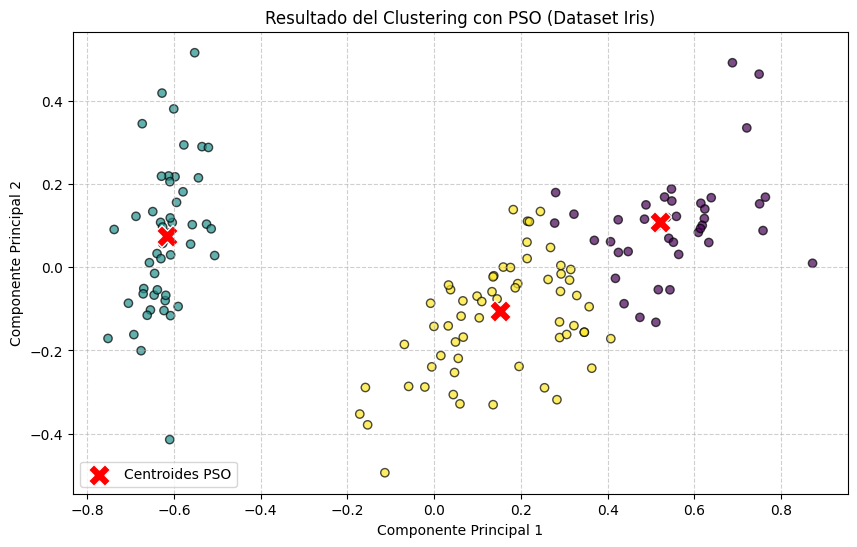

In [10]:
# Extraer centroides finales del mejor global
final_centers = gbest.reshape(num_clusters, dim)

# Asignar etiquetas finales basadas en los centroides encontrados
distances = np.linalg.norm(X[:, None] - final_centers, axis=2)
labels_pso = np.argmin(distances, axis=1)

# Reducción PCA a 2D para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
centers_pca = pca.transform(final_centers)

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso, cmap='viridis', alpha=0.7, edgecolors='k')
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='red', marker='X', s=250, label='Centroides PSO', edgecolors='white')

plt.title("Resultado del Clustering con PSO (Dataset Iris)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
print("-" * 30)
print("ANÁLISIS DE OPTIMIZACIÓN")
print("-" * 30)
print(f"Mejor Fitness Global (gbest_score): {gbest_score:.6f}")
print(f"Interpretación: Este valor indica la cohesión de los clústeres.")
print(f"A menor valor, mayor calidad del agrupamiento encontrado por el enjambre.")

------------------------------
ANÁLISIS DE OPTIMIZACIÓN
------------------------------
Mejor Fitness Global (gbest_score): 29.931243
Interpretación: Este valor indica la cohesión de los clústeres.
A menor valor, mayor calidad del agrupamiento encontrado por el enjambre.


hemos implementado y validado con éxito el algoritmo de Optimización por Enjambre de Partículas (PSO) aplicado a la tarea de clustering sobre el dataset Iris. A diferencia de los métodos tradicionales como K-Means, el uso de inteligencia colectiva mediante PSO permite una búsqueda global más robusta en el espacio de soluciones
La implementación cumple con el ciclo completo de los algoritmos de enjambre (representación, inicialización, fitness, comportamiento, evolución y finalización), logrando una separación coherente y precisa de los grupos a partir de los datos multidimensionales originales.